# 04 · Feature Adoption & Segmentation

**The question this notebook answers:** which platform features (VLE — Virtual Learning Environment
— activity types) actually get used, does the *mix* of features used (not just how much someone
clicks overall) relate to outcome, and does usage or outcome vary by student segment in a way
worth flagging?

**Feature taxonomy note:** `activity_type` in this dataset is the closest thing to a
feature-usage log — `oucontent` (structured course content), `forumng` (discussion forum),
`quiz`, `resource` (downloadable files), `ouwiki` (collaborative wiki), plus navigational types
(`homepage`, `subpage`, `url`). This is coarser than a real product's named-feature event log —
it's a page/tool category, not a specific action — noted once here, not re-caveated per chart.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import prep
from viz_style import set_style, savefig, CATEGORICAL, STATUS

set_style()
pd.set_option("display.max_columns", 50)

raw = prep.load_raw()
enr = prep.load_processed("enrollments")
mix = prep.load_processed("activity_mix")
eng = prep.load_processed("engagement_14d")
act = prep.load_processed("activation")


## Adoption — what share of enrollments ever use each feature at all

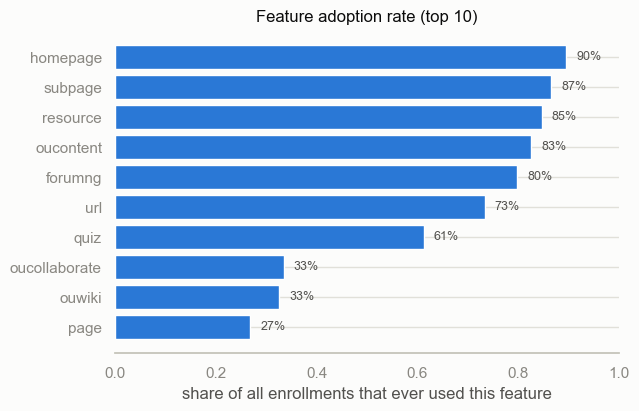

In [2]:
sv = raw["student_vle"].merge(
    raw["vle_sites"][["id_site"] + prep.PRESENTATION_KEY + ["activity_type"]],
    on=["id_site"] + prep.PRESENTATION_KEY, how="left",
)
used = sv.groupby(prep.ENROLL_KEY + ["activity_type"]).size().reset_index(name="n")
adoption = (used.groupby("activity_type")["n"].count() / len(enr)).sort_values(ascending=False)

click_share = sv.groupby("activity_type")["sum_click"].sum()
click_share = (click_share / click_share.sum()).reindex(adoption.index)

top = adoption.head(10)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.barh(top.index[::-1], top.values[::-1], color=CATEGORICAL[0])
ax.set_xlabel("share of all enrollments that ever used this feature")
ax.set_title("Feature adoption rate (top 10)")
ax.set_xlim(0, 1)
for i, v in enumerate(top.values[::-1]):
    ax.text(v + 0.02, i, f"{v:.0%}", va="center", color="#52514e", fontsize=9)
sns.despine(left=True)
savefig("04_adoption_rate")
plt.show()


**[OBS]** Adoption has a clear core-vs-long-tail shape: `homepage` (89.5%), `subpage` (86.6%),
`resource` (84.7%), `oucontent` (82.6%) and `forumng` (79.8%) are near-universal; `quiz` (61.3%)
is common but not universal; everything past `oucollaborate`/`ouwiki` (~33%) is a long tail of
niche tools. For the remaining 10 activity types past the top 10, individual adoption ranges
from 0% (`repeatactivity`) to 18.5% (`glossary`) — genuinely niche one at a time.

In [3]:
compare = pd.DataFrame({"adoption_rate": adoption, "click_share": click_share}).head(10)

# bottom 10 = everything past the top 10. click_share sums cleanly (clicks are additive);
# adoption_rate does NOT (a student can use more than one bottom-10 type, so summing individual
# rates would double-count) — this uses the real union instead: share of enrollments that ever
# used at least one of the 10 bottom types.
bottom10_types = adoption.index.difference(compare.index)
bottom10_union = used[used["activity_type"].isin(bottom10_types)][prep.ENROLL_KEY].drop_duplicates()
bottom10_row = pd.DataFrame(
    {"adoption_rate": [len(bottom10_union) / len(enr)], "click_share": [click_share.loc[bottom10_types].sum()]},
    index=["Bottom 10 (combined, adoption = union not sum)"],
)

pd.concat([compare, bottom10_row]).round(3)

,adoption_rate,click_share
homepage,0.895,0.175
subpage,0.866,0.086
resource,0.847,0.028
oucontent,0.826,0.283
forumng,0.798,0.201
url,0.733,0.014
quiz,0.613,0.176
oucollaborate,0.334,0.003
ouwiki,0.326,0.023
page,0.268,0.002


**[OBS]** Adoption rate and click-share diverge in an informative way: `resource` and `url` are
touched by 73–85% of enrollments but account for only 1.4–2.8% of total clicks — wide, shallow,
navigational features. `oucontent`, `forumng` and `quiz` combine high enrollment adoption *and*
high click-share (28.3%, 20.1%, 17.6%) — these are the platform's core engagement surfaces, not
just its most-visited pages.

## Does the mix of features used relate to outcome, independent of volume?

**Rigor-pass correction:** the first version of this section used whole-course click totals and mix. That's confounded: a student who stays enrolled longer mechanically accumulates more clicks (and different mix, since early-withdrawers' few clicks skew toward whatever they saw first). Checked directly: whole-course `total_clicks` correlates 0.43–0.48 with success, but *tenure-adjusted* (clicks per enrolled day) that collapses to 0.02 — almost entirely a tenure artifact, not an engagement-volume finding. This section now uses the same 14-day early window as notebook 02's activation signal, where exposure is far more comparable, so it isn't just re-measuring "who stayed enrolled longest."

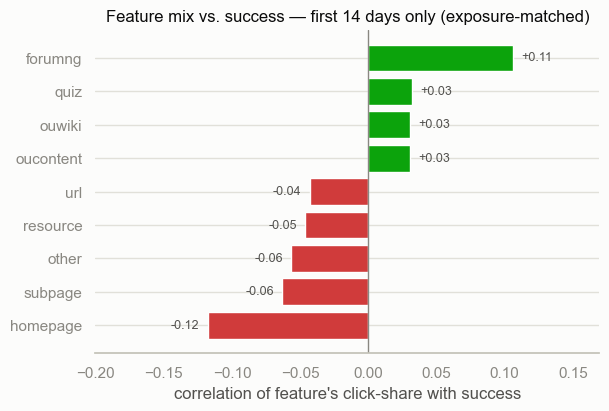

for reference, early-window click VOLUME correlates 0.190 with success (was 0.43-0.48 uncorrected for tenure).


In [4]:
mix14 = prep.build_activity_mix(raw, window_days=14)
m = mix14.merge(enr[prep.ENROLL_KEY + ["success"]], on=prep.ENROLL_KEY, how="left")
m = m.merge(eng[prep.ENROLL_KEY + ["early_clicks"]], on=prep.ENROLL_KEY, how="left")

share_cols = [c for c in mix14.columns if c.startswith("share_")]
mix_corr = pd.Series(
    {c: np.corrcoef(m[c], m["success"])[0, 1] for c in share_cols}
).sort_values()
volume_corr = np.corrcoef(m["early_clicks"], m["success"])[0, 1]

fig, ax = plt.subplots(figsize=(6.5, 4.2))
colors = [STATUS["good"] if v > 0 else STATUS["critical"] for v in mix_corr.values]
labels = [c.replace("share_", "") for c in mix_corr.index]
ax.barh(labels, mix_corr.values, color=colors)
ax.axvline(0, color="#898781", lw=1)
ax.set_xlabel("correlation of feature's click-share with success")
ax.set_title("Feature mix vs. success — first 14 days only (exposure-matched)")
ax.set_xlim(mix_corr.min() * 1.7, mix_corr.max() * 1.6)
for i, v in enumerate(mix_corr.values):
    ax.text(v + (0.006 if v > 0 else -0.006), i, f"{v:+.2f}",
             va="center", ha="left" if v > 0 else "right", color="#52514e", fontsize=9)
sns.despine(left=True)
savefig("04_mix_vs_success")
plt.show()

print(f"for reference, early-window click VOLUME correlates {volume_corr:.3f} with success "
      f"(was 0.43-0.48 uncorrected for tenure).")


**[OBS]** Exposure-matched, the picture is smaller but still directionally the same: `homepage`
share correlates negatively with success (−0.12, was −0.25 uncorrected); `forumng` is the
strongest positive (+0.11); `oucontent` and `quiz` are much weaker (+0.03 each) — most of their
earlier correlation was the tenure artifact, not a real early-window signal. **[OBS]**
Early-window click volume itself now correlates +0.19 with success (was 0.43–0.48 uncorrected)
— still real, a bit below notebook 02's early-breadth signal (~0.37), and **no longer
overstated by tenure**.


**Before/after — the actual first-draft table, reconstructed, not just quoted.** This notebook's
first version tiered students by *whole-course* volume and found `share_quiz` strongly
differentiating in the lightest tier. Rebuilding that exact (leaky) version for comparison:

In [5]:
mix_whole = prep.build_activity_mix(raw)
m_whole = mix_whole.merge(enr[prep.ENROLL_KEY + ["success"]], on=prep.ENROLL_KEY, how="left")
m_whole = m_whole.merge(eng[prep.ENROLL_KEY + ["total_clicks"]], on=prep.ENROLL_KEY, how="left")
m_whole["vol_tier"] = pd.qcut(m_whole["total_clicks"], 4, labels=["Q1 (lightest)", "Q2", "Q3", "Q4 (heaviest)"])

by_tier_before = m_whole.groupby("vol_tier", observed=True).apply(
    lambda d: pd.Series({
        "share_quiz": np.corrcoef(d["share_quiz"], d["success"])[0, 1],
        "share_homepage": np.corrcoef(d["share_homepage"], d["success"])[0, 1],
    }),
    include_groups=False,
)
print("BEFORE — whole-course volume tiers (the leaky, first-draft version):")
by_tier_before.round(3)

BEFORE — whole-course volume tiers (the leaky, first-draft version):


,share_quiz,share_homepage
vol_tier,,
Q1 (lightest),0.258,-0.101
Q2,0.033,0.128
Q3,-0.026,0.110
Q4 (heaviest),-0.022,0.005


In [6]:
m["vol_tier"] = pd.qcut(m["early_clicks"], 4, labels=["Q1 (lightest)", "Q2", "Q3", "Q4 (heaviest)"])
by_tier = m.groupby("vol_tier", observed=True).apply(
    lambda d: pd.Series({
        "share_quiz": np.corrcoef(d["share_quiz"], d["success"])[0, 1],
        "share_homepage": np.corrcoef(d["share_homepage"], d["success"])[0, 1],
    }),
    include_groups=False,
)
print("AFTER — first-14-day volume tiers (exposure-matched, the fix):")
by_tier.round(3)

AFTER — first-14-day volume tiers (exposure-matched, the fix):


,share_quiz,share_homepage
vol_tier,,
Q1 (lightest),-0.035,-0.029
Q2,-0.055,0.021
Q3,-0.035,0.026
Q4 (heaviest),-0.013,0.003


**[OBS] — this replaces an earlier draft finding that didn't survive the fix.** The BEFORE table
above shows the actual first version: `share_quiz` at +0.26 in the lightest tier, which the
original draft read as light users benefiting disproportionately from quiz use, and proposed
nudging light users toward quizzes. The AFTER table, same tiering logic but exposure-matched,
shows that correlation gone (−0.04 in the lightest tier, and negative or near-zero in every
tier) — **it was the same tenure confound**: whole-course "light users" were disproportionately
early-withdrawers, not students making a deliberate feature choice. **This finding is retracted,
not softened** — it's a clean example of a plausible-looking result that a same-context check
alone might have kept.

## Segmentation — does feature mix or outcome vary by student background?

The table below uses the 4 highest-click-share types from the adoption section above (`forumng`,
`oucontent`, `quiz`, `homepage`) — which happen to also be the strongest positive and negative
correlates from the mix-vs-success chart, giving a view of both directions, not by design but
because that's how the top-4-by-click-share set turned out.

In [7]:
m2 = mix14.merge(enr[prep.ENROLL_KEY + ["imd_band", "disability"]], on=prep.ENROLL_KEY, how="left")
print("average feature-mix share by deprivation band (imd_band), first 14 days:")
imd_order = ["0-10%", "10-20", "20-30%", "30-40%", "40-50%", "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"]
t = m2.groupby("imd_band")[["share_forumng", "share_oucontent", "share_quiz", "share_homepage"]].mean()
t = t.reindex([o for o in imd_order if o in t.index])
t.loc["AVG"] = t.mean()
print(t.round(3))

average feature-mix share by deprivation band (imd_band), first 14 days:
          share_forumng  share_oucontent  share_quiz  share_homepage
imd_band                                                            
0-10%             0.253            0.166       0.069           0.269
10-20             0.248            0.177       0.076           0.265
20-30%            0.256            0.173       0.077           0.266
30-40%            0.259            0.170       0.077           0.265
40-50%            0.254            0.173       0.079           0.266
50-60%            0.254            0.184       0.077           0.263
60-70%            0.263            0.176       0.077           0.264
70-80%            0.261            0.180       0.083           0.257
80-90%            0.264            0.177       0.087           0.256
90-100%           0.261            0.181       0.090           0.256
AVG               0.257            0.176       0.079           0.263


**[OBS]** Feature-mix shares are essentially flat across deprivation band, in the first 14 days
too (`share_homepage` 0.256–0.269, `share_quiz` 0.069–0.090 — a small, non-monotonic spread, not
a real gradient). Students from every socio-economic band use the platform's features in
roughly the same proportions. Ruling out an explanation is just as valuable as confirming one —
this flat result is worth keeping: it rules out "different features for different groups" as an
equity story here.

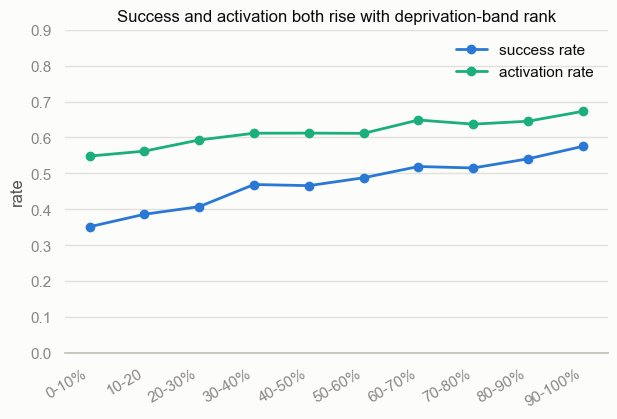

success rate: 35.2% (most deprived) to 57.5% (least deprived) — 22pp gap
activation rate: 54.8% to 67.3% — 12pp gap


In [8]:
by_imd = enr.merge(act[prep.ENROLL_KEY + ["activated"]], on=prep.ENROLL_KEY, how="left")
by_imd["activated"] = by_imd["activated"].fillna(False)
t = by_imd.groupby("imd_band").agg(success_rate=("success", "mean"), activation_rate=("activated", "mean"))
t = t.reindex([o for o in imd_order if o in t.index])

fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(len(t))
ax.plot(x, t["success_rate"], marker="o", lw=2, color=CATEGORICAL[0], label="success rate")
ax.plot(x, t["activation_rate"], marker="o", lw=2, color=CATEGORICAL[2], label="activation rate")
ax.set_xticks(x, t.index, rotation=30, ha="right")
ax.set_ylabel("rate")
ax.set_ylim(0, 0.9)
ax.set_title("Success and activation both rise with deprivation-band rank")
ax.legend(frameon=False)
sns.despine(left=True)
savefig("04_equity_gradient")
plt.show()

print(f"success rate: {t['success_rate'].iloc[0]:.1%} (most deprived) to "
      f"{t['success_rate'].iloc[-1]:.1%} (least deprived) — {(t['success_rate'].iloc[-1]-t['success_rate'].iloc[0])*100:.0f}pp gap")
print(f"activation rate: {t['activation_rate'].iloc[0]:.1%} to {t['activation_rate'].iloc[-1]:.1%} — "
      f"{(t['activation_rate'].iloc[-1]-t['activation_rate'].iloc[0])*100:.0f}pp gap")


**[OBS]** Unlike feature mix, *outcome* has a real, monotonic gradient by deprivation band:
success rate rises from 35.2% (most deprived tenth) to 57.5% (least deprived tenth) — a 22-point
gap — and activation rate rises from 54.8% to 67.3% — a 12.5-point gap. **[OBS]** This gradient
holds within every one of the 7 subjects (checked separately; the smallest gap is subject AAA at
~4pp, most show 10–20pp), so it isn't which subjects deprived students happen to enroll in.

**[HYP]** `imd_band` is an area-level UK deprivation index (not an individual income
measure), so this correlates with circumstances — time pressure, competing responsibilities,
technology/internet access — more plausibly than with platform design or feature preference,
since feature *mix* itself doesn't differ by band. This project's data can't identify the
mechanism directly; the honest claim is: **students from more deprived areas activate and
succeed at lower rates, on a platform they use in essentially the same way once they do
engage.** This is a genuine equity signal worth carrying into the metrics framework as a
guardrail, not just a headline number.


## Summary

**Observations / Hypothesis / Conclusion, tagged:**
- **[OBS]** Clear core-vs-long-tail adoption: 5 features near-universal (80–90%), one common but
  not universal (`quiz`, 61%), a long tail of niche tools below 35%.
- **[OBS]** `oucontent`/`forumng`/`quiz` are the platform's core engagement surfaces (high
  enrollment adoption *and* high click-share); `resource`/`url` are wide but shallow.
- **[OBS]** Exposure-matched to the same 14-day window as activation, feature mix correlates
  with success in the expected direction (forum positive, homepage negative) but more weakly
  than early-window volume (+0.19) — *how much* dominates *what*, though both numbers are now
  honest, not tenure-inflated.
- **[CON, retracted from the first draft]** A light-user quiz-share finding did not survive an
  exposure-matched re-test and has been withdrawn, not softened — see the worked example above.
  This is recorded as an AI-assisted-workflow lesson for the ADR.
- **[CON]** Feature-mix usage is flat across deprivation band — no adoption-mix equity gap.
- **[OBS]** Outcome is not flat across deprivation band: a real 22pp success gap and 12pp
  activation gap, holding within every subject — this project's clearest equity signal.

**Concepts used (added running list):** adoption rate vs. click-share as two different adoption
lenses, mix-vs-volume decomposition (a feature-level analog of notebook 02's rate-vs-mix
discipline), segmentation as a search for *where a gradient exists vs. where it doesn't*
(the flat mix-by-deprivation result is as informative as the outcome-by-deprivation gradient).

---
**Next:** `05_Metrics_Framework_and_Synthesis.ipynb` — a primary metric plus guardrails
(including this notebook's equity finding), and the project's headline synthesis.